# First Regression/Classification Model Pipeline

#### Proposed pipeline
`EMG + IMU → preprocessing/features → regression proxy (0–50) → discrete state → bilateral transition validation → accepted motor state`

The data contains:
- 8 EMG channels
- 6 IMUs (left/right thigh, shank, foot)
- each IMU has Accel X/Y/Z and Gyro X/Y/Z
- standing baseline + five-step walking trial

Time/history is used for **state-transition tracking and fault detection**, not future prediction.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


### 1. Load the Data

In [13]:
STANDING_FILE = "../Data/standing still z.xlsx"
WALKING_FILE = "../Data/Walking z 1.xlsx"

standing = pd.read_excel(STANDING_FILE)
walking = pd.read_excel(WALKING_FILE)

print("Standing:", standing.shape)
print("Walking :", walking.shape)
display(walking.head())

Standing: (32624, 45)
Walking : (12360, 45)


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
0,0.0000,-2.1386,0.4033,-17.1598,-3.3709,-5.4275,-0.1902,-2.9087,-3.6227,974.1211,34.5459,-264.8926,-17.4844,-0.7046,11.1875,1003.9,-157.7148,-210.8154,-24.3281,-11.7109,0.7275,292.4805,518.0664,804.1992,28.5156,-6.9961,-13.9062,909.1797,-361.8164,-192.6270,-3.1660,22.4062,4.4492,976.5625,119.9951,-235.4736,-18.3438,4.5195,-11.9219,-281.9824,414.5508,878.9062,22.4844,1.6807,-1.5576
1,0.0005,0.3029,-4.4798,-20.5170,-5.2020,-6.0378,-1.1058,-0.4672,-8.8110,973.2422,33.2626,-263.3545,-17.4312,-0.5538,11.0125,1004.4,-157.5073,-209.6069,-24.0219,-11.7094,0.8296,290.9424,517.7246,805.1270,28.2375,-6.9844,-13.8141,909.2285,-362.4268,-192.0654,-3.2521,22.3188,4.4898,976.0742,118.7500,-234.1309,-18.3078,4.4965,-11.9438,-283.6670,414.6729,880.0781,22.6969,1.7061,-1.5552
2,0.0010,2.1341,-10.5837,-22.6533,-6.7280,-5.4275,-2.0214,2.5848,-9.4214,972.3633,31.9794,-261.8164,-17.3781,-0.4029,10.8375,1004.9,-157.2998,-208.3984,-23.7156,-11.7078,0.9316,289.4043,517.3828,806.0547,27.9594,-6.9727,-13.7219,909.2773,-363.0371,-191.5039,-3.3383,22.2313,4.5305,975.5859,117.5049,-232.7881,-18.2719,4.4734,-11.9656,-285.3516,414.7949,881.2500,22.9094,1.7314,-1.5527
3,0.0015,4.2704,-17.2980,-22.6533,-5.8124,-3.5963,-2.3266,4.1107,-8.2006,971.4844,30.6961,-260.2783,-17.3250,-0.2521,10.6625,1005.4,-157.0923,-207.1899,-23.4094,-11.7062,1.0337,287.8662,517.0410,806.9824,27.6812,-6.9609,-13.6297,909.3262,-363.6475,-190.9424,-3.4244,22.1437,4.5711,975.0977,116.2598,-231.4453,-18.2359,4.4504,-11.9875,-287.0361,414.9170,882.4219,23.1219,1.7568,-1.5503
4,0.0020,7.3224,-22.7915,-21.7377,-5.5072,-0.2392,-2.3266,3.5004,-8.2006,970.6055,29.4128,-258.7402,-17.2719,-0.1013,10.4875,1005.9,-156.8848,-205.9814,-23.1031,-11.7047,1.1357,286.3281,516.6992,807.9102,27.4031,-6.9492,-13.5375,909.3750,-364.2578,-190.3809,-3.5105,22.0562,4.6117,974.6094,115.0146,-230.1025,-18.2000,4.4273,-12.0094,-288.7207,415.0391,883.5938,23.3344,1.7822,-1.5479


### 2. Group the Signals from the Dataset

In [15]:
time_col = 'Time_s'
emg_cols = list(walking.columns[1:9])
imu_cols = [c for c in walking.columns if c not in [time_col] + emg_cols]
left_cols = [c for c in imu_cols if '_L_' in c]
right_cols = [c for c in imu_cols if '_R_' in c]

print(f"EMG channels: {len(emg_cols)}")
print(f"IMU columns : {len(imu_cols)}")
print(f"Left IMU    : {len(left_cols)}")
print(f"Right IMU   : {len(right_cols)}")
print("EMG:", emg_cols)

EMG channels: 8
IMU columns : 36
Left IMU    : 18
Right IMU   : 18
EMG: ['Multifidus_R', 'Multifidus_L', 'ExternalOblique_R', 'ExternalOblique_L', 'RectusAbdominis_R', 'RectusAbdominis_L', 'ErectorSpinae_R', 'ErectorSpinae_L']


### 3. Validate the Data points

In [ ]:
def quality_report(df, name):
    dt = df[time_col].diff().dropna()
    print(f"--- {name} ---")
    print("Rows / columns:", df.shape)
    print("Missing cells:", int(df.isna().sum().sum()))
    print("Duplicate rows:", int(df.duplicated().sum()))
    print("Median sampling interval:", dt.median())
    print("Approx. sampling frequency:", 1 / dt.median(), "Hz")
    display(df.describe())
    print()

quality_report(standing, "Standing baseline")
quality_report(walking, "Walking")



--- Standing baseline ---
Rows / columns: (32624, 45)
Missing cells: 468
Duplicate rows: 0


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
count,32624.000000,32624.000000,32624.000000,32624.000000,32624.000000,32624.00000,32624.000000,32624.00000,32624.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000
mean,8.154300,-0.019371,-0.090044,-0.364465,0.029039,-0.00224,-0.023093,-0.00262,0.053266,978.620917,29.716522,-201.493739,-0.047586,0.068981,-0.035272,975.838008,-215.992446,-12.747979,0.011365,0.044316,-0.008752,265.288364,402.818604,874.320388,-0.001714,-0.025822,0.023425,933.920025,-301.983224,-190.159578,0.057716,-0.235246,-0.027483,933.978291,262.878600,-240.968979,0.058577,0.049816,0.089971,-305.597508,420.869547,851.419314,-0.003697,0.016967,0.018591
std,4.708103,5.560736,4.383451,5.808970,10.602722,2.29799,6.578318,7.45059,3.410939,13.373879,19.129055,24.613023,3.243143,3.152267,0.847522,2.586647,9.214250,4.976158,0.852384,0.369798,0.511564,1.220152,2.224455,1.310728,0.278672,0.187547,0.143207,13.886536,23.468520,36.973183,6.943517,3.291834,1.327018,3.675939,10.825556,4.977381,0.898564,0.391301,0.635920,1.435222,3.636853,2.073291,0.585246,0.217861,0.148406
min,0.000000,-33.886300,-22.070100,-22.042600,-103.756000,-11.59890,-31.764200,-54.31770,-28.334000,548.828100,-278.564500,-947.265600,-106.125000,-48.781200,-11.359400,944.824200,-262.695300,-39.215100,-9.203100,-1.395500,-2.576200,261.474600,381.591800,866.210900,-1.948200,-1.897500,-0.406200,589.843800,-882.324200,-1437.500000,-98.125000,-50.937500,-31.828100,905.761700,202.636700,-268.798800,-11.109400,-2.939500,-2.658200,-311.767600,392.578100,843.750000,-2.320300,-1.263700,-0.886700
25%,4.077175,-3.061700,-2.842800,-2.815400,-4.262700,-1.22230,-1.855100,-1.82430,-1.476900,977.441400,24.456800,-205.163600,-0.656100,-0.147700,-0.299000,974.316400,-221.600300,-16.640450,-0.297200,-0.185050,-0.236850,264.453100,401.025400,873.486300,-0.118200,-0.090400,-0.064700,932.617200,-306.835900,-195.629900,-0.485500,-0.533400,-0.289600,931.738300,257.177700,-244.482400,-0.265600,-0.183300,-0.223800,-306.543000,419.189500,850.097700,-0.205200,-0.058000,-0.051900
50%,8.154350,-0.009800,-0.096100,-0.373800,-0.905500,-0.00150,-0.023900,0.00690,0.049100,978.613300,27.850300,-201.489300,-0.129700,0.064400,-0.032500,975.488300,-218.383800,-12.367200,-0.027000,0.061900,-0.014600,265.185500,402.905300,874.414100,-0.005700,-0.018000,0.005700,934.228500,-299.877900,-191.894500,0.090200,-0.193800,0.078900,933.398400,263.916000,-241.528300,0.022100,0.041000,0.102900,-305.615200,421.777300,851.074200,-0.013700,0.018600,0.024100
75%,12.231425,3.347400,2.345500,1.762500,4.588000,1.21930,1.502000,2.14320,1.880300,979.736300,31.428500,-198.034700,0.518600,0.247700,0.213650,977.148400,-210.009800,-8.768100,0.257350,0.272700,0.227700,265.918000,404.394500,875.293000,0.108600,0.056000,0.086100,935.791000,-294.921900,-186.352500,0.659700,0.080850,0.358200,935.742200,268.554700,-237.719700,0.392550,0.316800,0.435700,-304.687500,423.242200,852.29490


--- Walking ---
Rows / columns: (12360, 45)
Missing cells: 1500
Duplicate rows: 0


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
count,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000,12360.00000,12360.000000,12360.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12155.000000,12155.000000,12155.000000,12155.000000,12155.000000,12155.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000
mean,3.089201,0.004949,0.103355,0.250528,-0.022170,-0.246093,0.11841,-0.159507,0.041730,929.246014,221.861760,-274.646621,1.143490,-1.647799,-0.845781,912.475351,-315.976376,-32.997757,2.691269,-2.880489,0.238143,436.902637,446.219496,810.449863,2.513730,-0.492495,0.658093,894.428105,-424.142501,-53.858108,-0.037375,0.333859,1.772468,893.311734,287.470397,-247.682300,-1.217312,-0.999502,0.985021,-441.114541,440.718678,820.516637,1.283617,0.210593,-1.105969
std,1.783766,6.048253,5.744603,8.279721,13.014305,5.093194,7.71961,8.578955,5.177035,73.041703,145.161406,106.509179,26.872872,15.199340,33.769506,189.104122,261.837394,108.803362,43.693585,21.792167,83.251326,303.316334,163.734062,149.200017,44.812369,86.442629,53.336776,101.894309,97.258811,156.877961,34.690124,30.743677,18.926519,176.622503,255.278551,132.451589,35.361306,30.123019,70.042316,339.636098,236.107113,231.519471,27.780000,99.145320,41.851061
min,0.000000,-44.560700,-52.090200,-45.237700,-133.383700,-27.401500,-40.78100,-60.895700,-30.479800,727.050800,-93.566900,-577.636700,-75.187500,-37.687500,-97.937500,298.095700,-1088.900000,-295.166000,-161.625000,-74.062500,-243.000000,-1338.900000,-44.769300,62.927200,-160.375000,-328.500000,-158.875000,392.822300,-759.277300,-324.462900,-86.375000,-57.375000,-30.437500,312.255900,-360.351600,-736.328100,-87.625000,-77.375000,-116.875000,-2240.200000,-1067.400000,-248.535200,-119.812500,-272.000000,-129.125000
25%,1.544575,-3.054200,-2.953900,-3.731300,-3.370900,-2.985900,-2.63170,-3.213900,-2.401900,895.996100,126.586900,-356.298800,-16.030900,-10.493000,-9.906250,930.224600,-419.970700,-118.402100,-12.530650,-16.009400,2.922550,289.794900,377.063000,782.324200,-14.442200,-20.056200,-3.799550,852.539100,-480.224600,-187.963900,-22.176550,-20.905450,-11.435900,885.766600,145.556650,-330.603000,-22.607850,-18.341450,-34.445350,-514.953600,356.762700,759.741200,-12.278900,-15.109400,-13.788300
50%,3.089250,-0.002300,0.098100,0.236300,-0.013700,-0.239200,0.11500,-0.162000,0.039700,926.513700,184.997600,-301.757800,1.941700,-3.347700,8.353500,970.507800,-284.619100,-64.752200,7.584400,-1.795000,23.853100,318.066400,437.133800,845.996100,-2.694100,1.508800,4.046900,889.648400,-420.117200,-93.322800,-3.128900,-5.546900,-2.389100,929.492200,248.046900,-266.601600,-3.536900,-9.675800,-19.156200,-325.708000,423.559600,849.511700,1.500000,0.725600,-1.909000
75%,4.633825,3.049700,3.150000,3.898600,3.953800,2.507600,2.86180,2.890000,2.786400,951.953100,285.070800,-190.405300,19.748450,3.056650,20.850800,998.779300,-187.292500,46.987950,21.490650,6.782000,47.035950,518.859900,503.515600,881.982400,21.639050,11.397250,28.060950,931.884800,-369.165050,69.397000,18.734400,13.875400,9.3

In [ ]:
print("Standing missing values by column:")
display(standing.isna().sum()[standing.isna().sum() > 0])

print("Walking missing values by column:")
display(walking.isna().sum()[walking.isna().sum() > 0])

### 4. Visualize EMG: standing vs walking

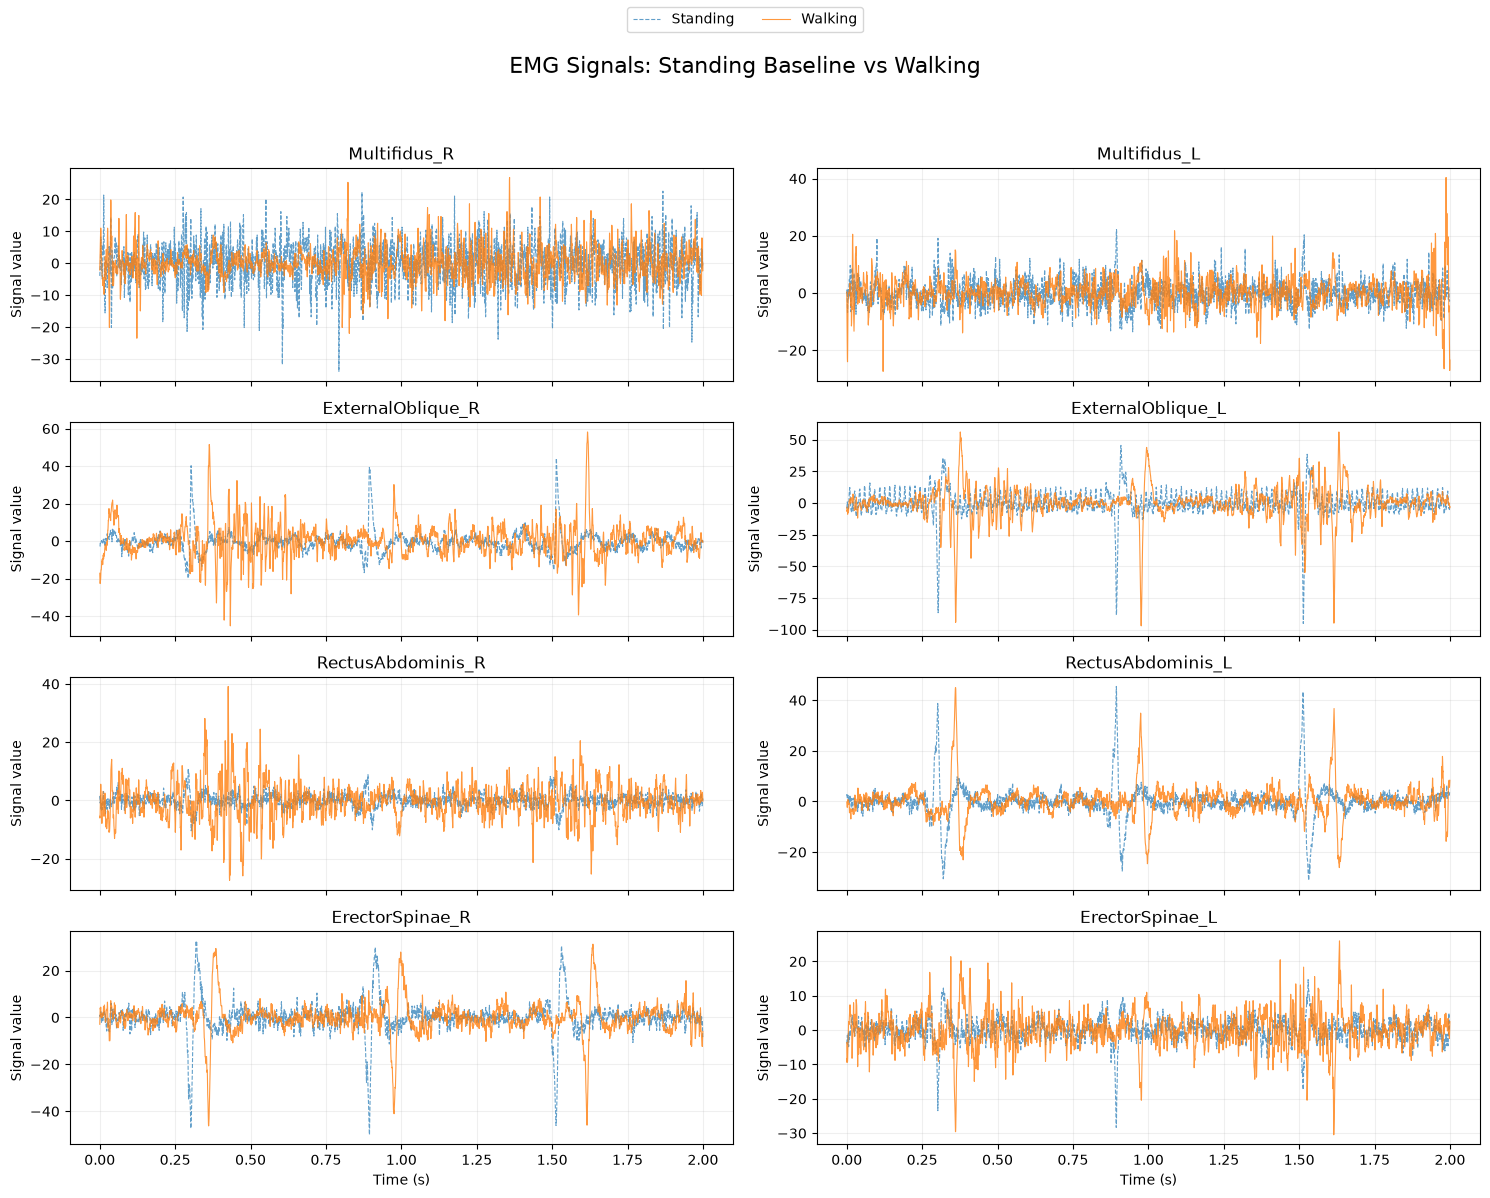

In [30]:
def compare_emg_channels(standing, walking, cols, seconds=2.0):
    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(15, 12),
        sharex=True
    )
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        stand_part = standing[standing[time_col] <= standing[time_col].iloc[0] + seconds]
        walk_part = walking[walking[time_col] <= walking[time_col].iloc[0] + seconds]

        # Shift time so both start at 0
        stand_time = stand_part[time_col] - stand_part[time_col].iloc[0]
        walk_time = walk_part[time_col] - walk_part[time_col].iloc[0]

        # Plot both conditions
        ax.plot(
            stand_time,
            stand_part[col],
            label="Standing",
            linewidth=0.8,
            linestyle="--",
            alpha=0.7
        )
        ax.plot(
            walk_time,
            walk_part[col],
            label="Walking",
            linewidth=0.8,
            linestyle="-",
            alpha=0.8
        )
        ax.set_title(col)
        ax.set_ylabel("Signal value")
        ax.grid(alpha=0.2)

    # X label only needed at bottom
    for ax in axes[-2:]:
        ax.set_xlabel("Time (s)")

    # One shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2
    )
    fig.suptitle(
        "\nEMG Signals: Standing Baseline vs Walking",
        fontsize=16,
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

compare_emg_channels(
    standing,
    walking,
    emg_cols,
    seconds=2.0
)

### 5. Visualize IMU: bilateral thigh/shank/foot motion

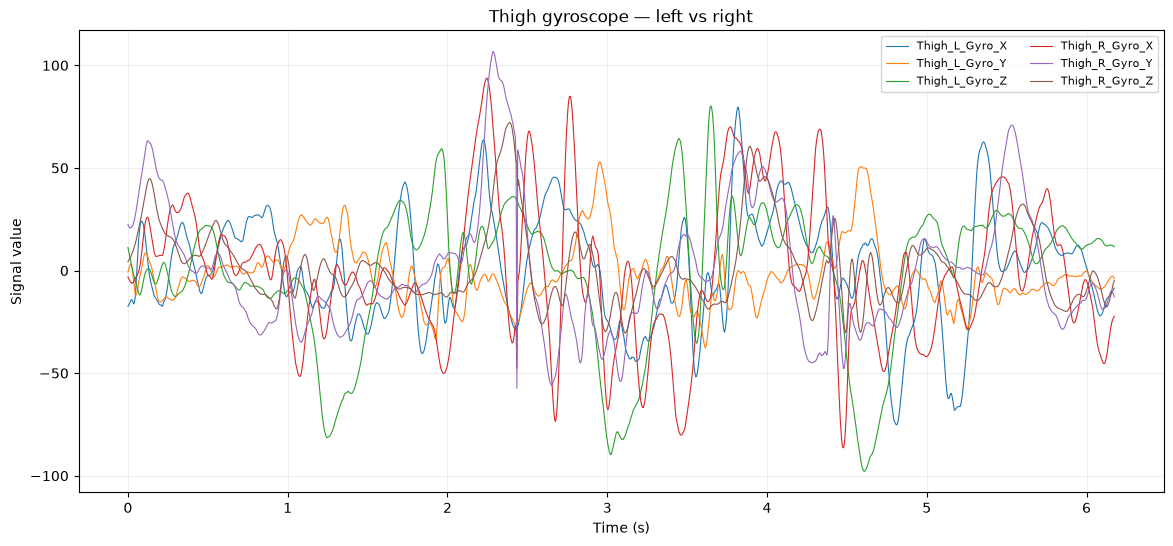

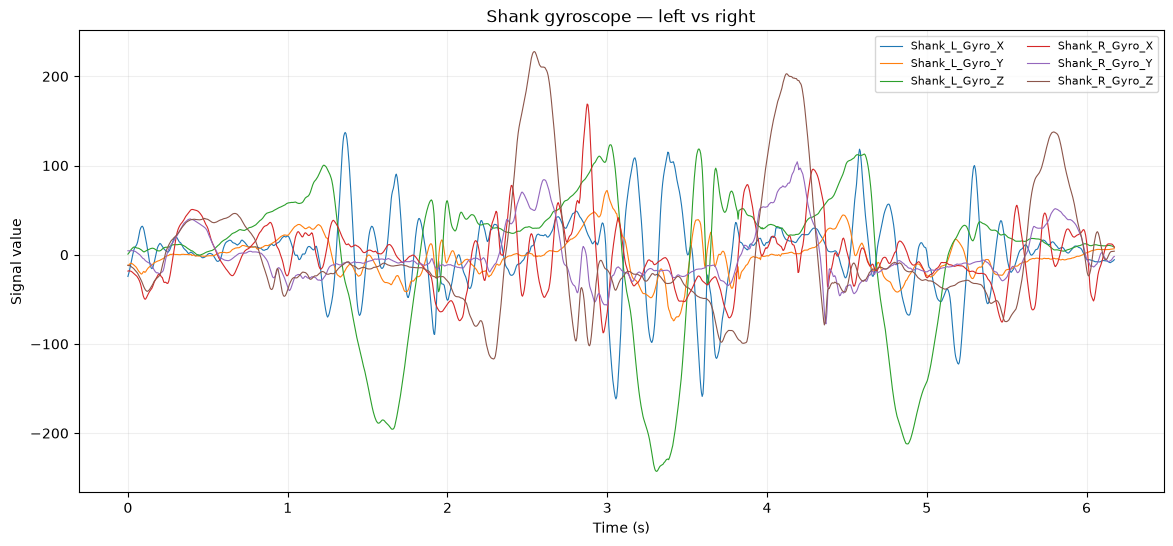

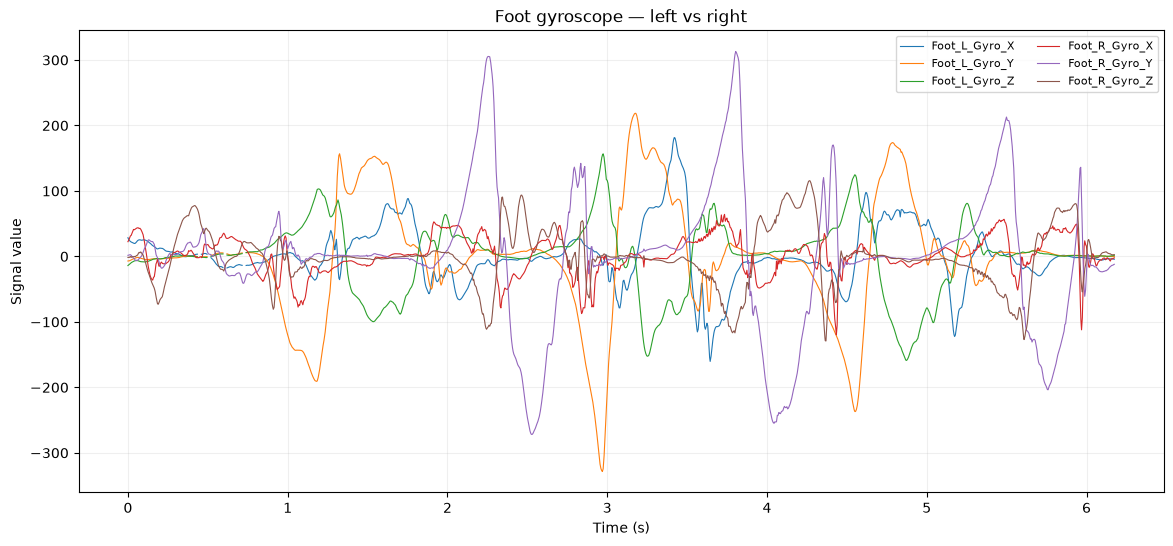

In [32]:
for segment in ['Thigh', 'Shank', 'Foot']:
    cols = [f'{segment}_L_Gyro_X', f'{segment}_L_Gyro_Y', f'{segment}_L_Gyro_Z',
            f'{segment}_R_Gyro_X', f'{segment}_R_Gyro_Y', f'{segment}_R_Gyro_Z']
    plot_channels(walking, cols, f"{segment} gyroscope — left vs right", seconds=walking[time_col].iloc[-1])

### 6. Baseline normalization

In [33]:
signal_cols = emg_cols + imu_cols
baseline_mean = standing[signal_cols].mean()
walking_zeroed = walking.copy()
walking_zeroed[signal_cols] = walking[signal_cols] - baseline_mean

display(walking_zeroed.head())

,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
0,0.0000,-2.119229,0.493344,-16.795335,-3.399939,-5.42526,-0.167107,-2.90608,-3.675966,-4.499817,4.829378,-63.398861,-17.436814,-0.773581,11.222772,28.061992,58.277646,-198.067421,-24.339465,-11.755216,0.736252,27.192136,115.247796,-70.121188,28.517314,-6.970278,-13.929625,-24.740325,-59.833176,-2.467422,-3.223716,22.641446,4.476683,42.584209,-142.8835,5.495379,-18.402377,4.469684,-12.011871,23.615108,-6.318747,27.486886,22.488097,1.663733,-1.576191
1,0.0005,0.322271,-4.389756,-20.152535,-5.231039,-6.03556,-1.082707,-0.46458,-8.864266,-5.378717,3.546078,-61.860761,-17.383614,-0.622781,11.047772,28.561992,58.485146,-196.858921,-24.033265,-11.753716,0.838352,25.654036,114.905996,-69.193388,28.239214,-6.958578,-13.837525,-24.691525,-60.443576,-1.905822,-3.309816,22.554046,4.517283,42.095909,-144.1286,6.838079,-18.366377,4.446684,-12.033771,21.930508,-6.196647,28.658786,22.700597,1.689133,-1.573791
2,0.0010,2.153471,-10.493656,-22.288835,-6.757039,-5.42526,-1.998307,2.58742,-9.474666,-6.257617,2.262878,-60.322661,-17.330514,-0.471881,10.872772,29.061992,58.692646,-195.650421,-23.726965,-11.752116,0.940352,24.115936,114.564196,-68.265688,27.961114,-6.946878,-13.745325,-24.642725,-61.053876,-1.344322,-3.396016,22.466546,4.557983,41.607609,-145.3737,8.180879,-18.330477,4.423584,-12.055571,20.245908,-6.074647,29.830686,22.913097,1.714433,-1.571291
3,0.0015,4.289771,-17.207956,-22.288835,-5.841439,-3.59406,-2.303507,4.11332,-8.253866,-7.136517,0.979578,-58.784561,-17.277414,-0.321081,10.697772,29.561992,58.900146,-194.441921,-23.420765,-11.750516,1.042452,22.577836,114.222396,-67.337988,27.682914,-6.935078,-13.653125,-24.593825,-61.664276,-0.782822,-3.482116,22.378946,4.598583,41.119409,-146.6188,9.523679,-18.294477,4.400584,-12.077471,18.561408,-5.952547,31.002586,23.125597,1.739833,-1.568891
4,0.0020,7.341771,-22.701456,-21.373235,-5.536239,-0.23696,-2.303507,3.50302,-8.253866,-8.015417,-0.303722,-57.246461,-17.224314,-0.170281,10.522772,30.061992,59.107646,-193.233421,-23.114465,-11.749016,1.144452,21.039736,113.880596,-66.410188,27.404814,-6.923378,-13.560925,-24.545025,-62.274576,-0.221322,-3.568216,22.291446,4.639183,40.631109,-147.8640,10.866479,-18.258577,4.377484,-12.099371,16.876808,-5.830447,32.174486,23.338097,1.765233,-1.566491


### 7. Generate Bilateral Movement Scores
Standing thigh IMU --> Find neutral orientation

Walking thigh IMU --> Compare against neutral --> Movement magnitude --> Normalize --> Left movement score  0–1 & Right movement score 0–1

In [34]:
# 7.1 Estimate thigh orientation from the IMU
def accel_tilt_deg(df, side):
    """
    Estimate thigh sensor tilt from accelerometer measurements.

    Note:
    This represents sensor orientation, NOT the actual hip joint angle.
    """

    x = df[f'Thigh_{side}_Accel_X'].to_numpy()
    y = df[f'Thigh_{side}_Accel_Y'].to_numpy()
    z = df[f'Thigh_{side}_Accel_Z'].to_numpy()

    tilt = np.degrees(
        np.arctan2(
            np.sqrt(x**2 + y**2),
            z
        )
    )

    return tilt

In [35]:
# 7.2 Determine the neutral standing position
# Calculate thigh orientation during standing
standing_tilt_L = accel_tilt_deg(standing, 'L')
standing_tilt_R = accel_tilt_deg(standing, 'R')

# Median standing orientation = neutral reference
neutral_L = np.nanmedian(standing_tilt_L)
neutral_R = np.nanmedian(standing_tilt_R)

print(f"Left neutral orientation:  {neutral_L:.2f}°")
print(f"Right neutral orientation: {neutral_R:.2f}°")

Left neutral orientation:  101.63°
Right neutral orientation: 101.06°


In [36]:
# 7.3 Measure movement away from neutral
# Create working copy of walking data
walking_work = walking.copy()

# Calculate thigh orientation during walking
walking_tilt_L = accel_tilt_deg(walking, 'L')
walking_tilt_R = accel_tilt_deg(walking, 'R')

# Movement relative to standing neutral
walking_work['Movement_L'] = np.abs(
    walking_tilt_L - neutral_L
)

walking_work['Movement_R'] = np.abs(
    walking_tilt_R - neutral_R
)

In [37]:
# 7.4 Normalize each leg to a 0–1 movement score
def normalize_movement_score(values):
    """
    Convert movement magnitude into a normalized 0-1 score.

    The 95th percentile is used as the high-movement reference
    to reduce the effect of extreme sensor spikes.
    """

    values = np.asarray(values)

    high = np.nanpercentile(values, 95)

    if high <= 0:
        return np.zeros_like(values)

    score = values / high

    return np.clip(score, 0, 1)


walking_work['MovementScore_L'] = normalize_movement_score(
    walking_work['Movement_L']
)

walking_work['MovementScore_R'] = normalize_movement_score(
    walking_work['Movement_R']
)

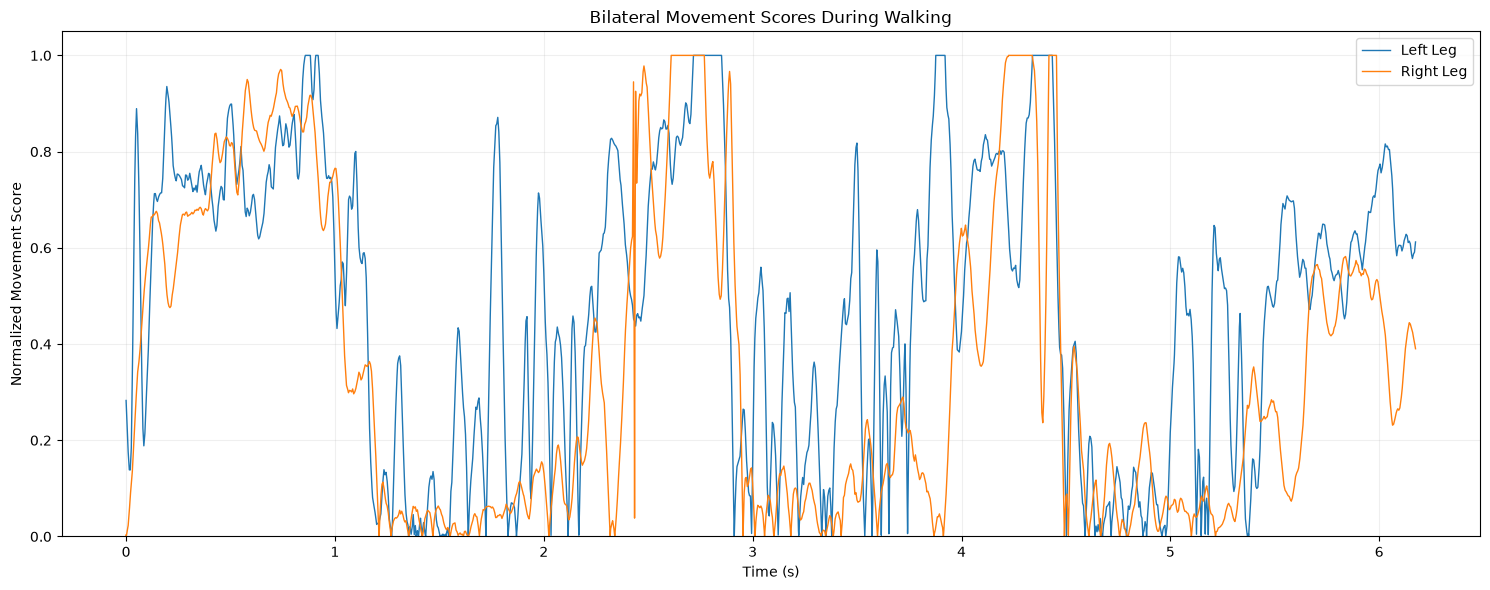

In [38]:
# 7.5 Plot left and right movement scores
plt.figure(figsize=(15, 6))

plt.plot(
    walking_work[time_col],
    walking_work['MovementScore_L'],
    label='Left Leg',
    linewidth=1
)

plt.plot(
    walking_work[time_col],
    walking_work['MovementScore_R'],
    label='Right Leg',
    linewidth=1
)

plt.title('Bilateral Movement Scores During Walking')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Movement Score')

plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [39]:
# 7.6 Quick check of the generated scores
walking_work[
    ['MovementScore_L', 'MovementScore_R']
].describe()

,MovementScore_L,MovementScore_R
count,12351.000000,12351.000000
mean,0.484245,0.357214
std,0.300215,0.325473
min,0.000040,0.000015
25%,0.190159,0.063643
50%,0.519919,0.241340
75%,0.738380,0.626511
max,1.000000,1.000000


### 8. Convert Movement Scores into Bilateral States

In [ ]:
# 8.1 Convert movement score to state

N_STATES = 10

def score_to_state(score, n_states=N_STATES):
    """
    Convert a normalized movement score (0-1)
    into a discrete state.

    Example with 10 states:
    0.00-0.10 -> S0
    0.10-0.20 -> S1
    ...
    0.90-1.00 -> S9
    """

    state = np.floor(score * n_states).astype(int)

    # A score of exactly 1.0 would give state 10,
    # so restrict the maximum to state 9.
    state = np.clip(state, 0, n_states - 1)

    return state


walking_work['State_L'] = score_to_state(
    walking_work['MovementScore_L']
)

walking_work['State_R'] = score_to_state(
    walking_work['MovementScore_R']
)

In [ ]:
# 8.2 Create the bilateral state
walking_work['BilateralState'] = (
    'L' + walking_work['State_L'].astype(str)
    + '_R'
    + walking_work['State_R'].astype(str)
)

In [ ]:
walking_work[
    [
        time_col,
        'MovementScore_L',
        'State_L',
        'MovementScore_R',
        'State_R',
        'BilateralState'
    ]
].head(20)

In [ ]:
# 8.3 Check how frequently each state occurs
print("LEFT LEG STATE COUNTS")
print(
    walking_work['State_L']
    .value_counts()
    .sort_index()
)

print("\nRIGHT LEG STATE COUNTS")
print(
    walking_work['State_R']
    .value_counts()
    .sort_index()
)

In [ ]:
left_percent = (
    walking_work['State_L']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

right_percent = (
    walking_work['State_R']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

state_distribution = pd.DataFrame({
    'Left (%)': left_percent,
    'Right (%)': right_percent
}).fillna(0)

state_distribution

In [ ]:
# 8.4 Visualize the states
plt.figure(figsize=(15, 6))

plt.step(
    walking_work[time_col],
    walking_work['State_L'],
    where='post',
    label='Left Leg',
    linewidth=1
)

plt.step(
    walking_work[time_col],
    walking_work['State_R'],
    where='post',
    label='Right Leg',
    linewidth=1
)

plt.title('Bilateral Movement States During Walking')
plt.xlabel('Time (s)')
plt.ylabel('Movement State')

plt.yticks(
    range(N_STATES),
    [f'S{i}' for i in range(N_STATES)]
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 9. Visualize and Inspect Bilateral State Progression

In [ ]:
# 9.1 Plot left and right states separately
# ============================================================
# 9. Visualize and Inspect Bilateral State Progression
# ============================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True
)

# Left leg
axes[0].step(
    walking_work[time_col],
    walking_work['State_L'],
    where='post',
    linewidth=1
)

axes[0].set_title('Left Leg State Progression')
axes[0].set_ylabel('State')
axes[0].set_yticks(
    range(N_STATES),
    [f'S{i}' for i in range(N_STATES)]
)
axes[0].grid(alpha=0.2)


# Right leg
axes[1].step(
    walking_work[time_col],
    walking_work['State_R'],
    where='post',
    linewidth=1
)

axes[1].set_title('Right Leg State Progression')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('State')
axes[1].set_yticks(
    range(N_STATES),
    [f'S{i}' for i in range(N_STATES)]
)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# 9.2 Plot left and right together
plt.figure(figsize=(15, 6))

plt.step(
    walking_work[time_col],
    walking_work['State_L'],
    where='post',
    label='Left Leg',
    linewidth=1.2
)

plt.step(
    walking_work[time_col],
    walking_work['State_R'],
    where='post',
    label='Right Leg',
    linewidth=1.2,
    alpha=0.75
)

plt.title('Bilateral State Progression During Walking')
plt.xlabel('Time (s)')
plt.ylabel('Movement State')

plt.yticks(
    range(N_STATES),
    [f'S{i}' for i in range(N_STATES)]
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# 9.3 Create state-change columns
walking_work['StateChange_L'] = (
    walking_work['State_L']
    != walking_work['State_L'].shift(1)
)

walking_work['StateChange_R'] = (
    walking_work['State_R']
    != walking_work['State_R'].shift(1)
)

walking_work['BilateralChange'] = (
    walking_work['StateChange_L']
    | walking_work['StateChange_R']
)

In [ ]:
# 9.4 Extract only bilateral state changes
state_changes = walking_work.loc[
    walking_work['BilateralChange'],
    [
        time_col,
        'State_L',
        'State_R',
        'BilateralState'
    ]
].copy()

state_changes.head(30)

In [ ]:
# 9.5 Check how many state changes occurred
print("Total samples:", len(walking_work))
print("Bilateral state changes:", len(state_changes))

print(
    "Left state changes:",
    walking_work['StateChange_L'].sum()
)

print(
    "Right state changes:",
    walking_work['StateChange_R'].sum()
)

In [ ]:
# 9.6 See the most common bilateral states
bilateral_counts = (
    walking_work['BilateralState']
    .value_counts()
    .reset_index()
)

bilateral_counts.columns = [
    'Bilateral State',
    'Sample Count'
]

bilateral_counts.head(15)

### 10. Analyze Bilateral State Transitions

In [ ]:
walking_work['Prev_State_L'] = walking_work['State_L'].shift(1)
walking_work['Prev_State_R'] = walking_work['State_R'].shift(1)

walking_work['DeltaState_L'] = walking_work['State_L'] - walking_work['Prev_State_L']
walking_work['DeltaState_R'] = walking_work['State_R'] - walking_work['Prev_State_R']

transition_rows = walking_work.loc[
    (walking_work['DeltaState_L'] != 0) |
    (walking_work['DeltaState_R'] != 0),
    [
        time_col,
        'Prev_State_L', 'State_L',
        'Prev_State_R', 'State_R',
        'DeltaState_L', 'DeltaState_R',
        'BilateralState'
    ]
].dropna().copy()

transition_rows.head(20)

In [ ]:
print("Number of observed bilateral transitions:", len(transition_rows))

print("\nLeft state-change size:")
print(transition_rows['DeltaState_L'].value_counts().sort_index())

print("\nRight state-change size:")
print(transition_rows['DeltaState_R'].value_counts().sort_index())

In [ ]:
bilateral_state_counts = (
    walking_work['BilateralState']
    .value_counts()
    .rename_axis('BilateralState')
    .reset_index(name='Count')
)

bilateral_state_counts['Percentage'] = (
    100 * bilateral_state_counts['Count'] / len(walking_work)
)

bilateral_state_counts.head(20)

### 11. Prepare the Machine-Learning Dataset

In [ ]:
label_source_cols = [
    'Thigh_L_Accel_X', 'Thigh_L_Accel_Y', 'Thigh_L_Accel_Z',
    'Thigh_R_Accel_X', 'Thigh_R_Accel_Y', 'Thigh_R_Accel_Z'
]

sensor_cols = emg_cols + imu_cols

feature_cols = [
    c for c in sensor_cols
    if c not in label_source_cols and c in walking_work.columns
]

print("Number of model features:", len(feature_cols))
print("\nExcluded label-source columns:")
print(label_source_cols)

In [ ]:
X = walking_work[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
y = walking_work[['State_L', 'State_R']].copy()

X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

### Time-aware train/test split

Neighboring sensor samples are highly similar, so do not randomly shuffle individual rows. Use the earlier portion for training and the later portion for testing.

In [ ]:
TRAIN_RATIO = 0.80

split_index = int(len(X) * TRAIN_RATIO)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

time_train = walking_work[time_col].iloc[:split_index].copy()
time_test = walking_work[time_col].iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print(f"Training time: {time_train.iloc[0]:.3f} to {time_train.iloc[-1]:.3f} s")
print(f"Testing time:  {time_test.iloc[0]:.3f} to {time_test.iloc[-1]:.3f} s")

### 12. Train the Initial Bilateral State Classifier

In [ ]:
state_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

state_model.fit(X_train, y_train)

y_pred = state_model.predict(X_test)

pred_L = y_pred[:, 0]
pred_R = y_pred[:, 1]

print("Model training complete.")

### 13. Evaluate the State Classifier

In [ ]:
accuracy_L = accuracy_score(y_test['State_L'], pred_L)
accuracy_R = accuracy_score(y_test['State_R'], pred_R)

print(f"Left state accuracy:  {accuracy_L:.3f}")
print(f"Right state accuracy: {accuracy_R:.3f}")

In [ ]:
print("LEFT LEG CLASSIFICATION REPORT")
print(classification_report(y_test['State_L'], pred_L, zero_division=0))

print("\nRIGHT LEG CLASSIFICATION REPORT")
print(classification_report(y_test['State_R'], pred_R, zero_division=0))

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].step(time_test, y_test['State_L'], where='post',
             label='Actual', linewidth=1.2)
axes[0].step(time_test, pred_L, where='post',
             label='Predicted', linewidth=1.0, alpha=0.75)
axes[0].set_title('Left Leg: Actual vs Predicted State')
axes[0].set_ylabel('State')
axes[0].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].step(time_test, y_test['State_R'], where='post',
             label='Actual', linewidth=1.2)
axes[1].step(time_test, pred_R, where='post',
             label='Predicted', linewidth=1.0, alpha=0.75)
axes[1].set_title('Right Leg: Actual vs Predicted State')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('State')
axes[1].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test['State_L'], pred_L,
    labels=range(N_STATES),
    display_labels=[f'S{i}' for i in range(N_STATES)],
    ax=ax,
    colorbar=False
)
ax.set_title('Left Leg State Confusion Matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test['State_R'], pred_R,
    labels=range(N_STATES),
    display_labels=[f'S{i}' for i in range(N_STATES)],
    ax=ax,
    colorbar=False
)
ax.set_title('Right Leg State Confusion Matrix')
plt.tight_layout()
plt.show()

### 14. Bilateral Transition Validation and Fault Detection

In [ ]:
MAX_STATE_JUMP = 2

test_results = pd.DataFrame({
    time_col: time_test.to_numpy(),
    'ActualState_L': y_test['State_L'].to_numpy(),
    'ActualState_R': y_test['State_R'].to_numpy(),
    'CandidateState_L': pred_L,
    'CandidateState_R': pred_R
})

accepted_L = []
accepted_R = []
fault_flags = []

prev_L = int(test_results['CandidateState_L'].iloc[0])
prev_R = int(test_results['CandidateState_R'].iloc[0])

for _, row in test_results.iterrows():
    cand_L = int(row['CandidateState_L'])
    cand_R = int(row['CandidateState_R'])

    jump_L = abs(cand_L - prev_L)
    jump_R = abs(cand_R - prev_R)

    fault = (jump_L > MAX_STATE_JUMP) or (jump_R > MAX_STATE_JUMP)

    if fault:
        accepted_L.append(prev_L)
        accepted_R.append(prev_R)
        fault_flags.append(True)
    else:
        prev_L = cand_L
        prev_R = cand_R
        accepted_L.append(prev_L)
        accepted_R.append(prev_R)
        fault_flags.append(False)

test_results['AcceptedState_L'] = accepted_L
test_results['AcceptedState_R'] = accepted_R
test_results['FaultFlag'] = fault_flags

print("Detected transition faults:", test_results['FaultFlag'].sum())

test_results.head(20)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].step(test_results[time_col], test_results['CandidateState_L'],
             where='post', label='Candidate', alpha=0.6)
axes[0].step(test_results[time_col], test_results['AcceptedState_L'],
             where='post', label='Accepted', linewidth=1.2)
axes[0].set_title('Left Leg: Candidate vs Accepted State')
axes[0].set_ylabel('State')
axes[0].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].step(test_results[time_col], test_results['CandidateState_R'],
             where='post', label='Candidate', alpha=0.6)
axes[1].step(test_results[time_col], test_results['AcceptedState_R'],
             where='post', label='Accepted', linewidth=1.2)
axes[1].set_title('Right Leg: Candidate vs Accepted State')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('State')
axes[1].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 15. Motor-State Mapping

In [ ]:
def state_to_motor_command(state):
    if N_STATES <= 1:
        return 0.0
    return state / (N_STATES - 1)

test_results['MotorCommand_L'] = (
    test_results['AcceptedState_L'].apply(state_to_motor_command)
)

test_results['MotorCommand_R'] = (
    test_results['AcceptedState_R'].apply(state_to_motor_command)
)

test_results[
    [
        time_col,
        'AcceptedState_L', 'MotorCommand_L',
        'AcceptedState_R', 'MotorCommand_R',
        'FaultFlag'
    ]
].head(20)

In [ ]:
plt.figure(figsize=(15, 6))

plt.step(test_results[time_col], test_results['MotorCommand_L'],
         where='post', label='Left Motor Command')

plt.step(test_results[time_col], test_results['MotorCommand_R'],
         where='post', label='Right Motor Command', alpha=0.8)

plt.title('Prototype Bilateral Motor Commands')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Motor Command')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 16. Feature Importance

In [ ]:
feature_importance = pd.Series(
    state_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance.head(15)

In [ ]:
top_n = 15

plt.figure(figsize=(10, 7))
feature_importance.head(top_n).sort_values().plot(kind='barh')

plt.title(f'Top {top_n} Model Features')
plt.xlabel('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### 17. Export Results

In [ ]:
output_file = 'bilateral_state_results.csv'

test_results.to_csv(output_file, index=False)

print("Saved:", output_file)